In [20]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from transformers import AutoTokenizer
from pathlib import Path



In [21]:
CSV_PATH = Path(r"D:\multimodal-clinical-ai\multimodal-clinical-ai\data\metadata\patient_index.csv")

df = pd.read_csv(CSV_PATH)

print("Total samples:", len(df))
df.head()


Total samples: 30623


,image_path,findings,impression,label
0,data\raw\images\img_0.png,"The lungs are clear of focal consolidation, pl...",No acute cardiopulmonary process.,NORMAL
1,data\raw\images\img_1.png,Lung volumes remain low. There are innumerable...,Low lung volumes and mild pulmonary vascular c...,PNEUMONIA
2,data\raw\images\img_2.png,Lung volumes are low. This results in crowding...,Innumerable pulmonary metastases. Possible mil...,EDEMA
3,data\raw\images\img_3.png,In comparison to study performed on of there i...,New mild pulmonary edema with persistent small...,EDEMA
4,data\raw\images\img_4.png,The right costophrenic angle is not imaged. Ot...,An enteric tube courses below the level of the...,OTHER


In [22]:
LABEL2ID = {
    "NORMAL": 0,
    "PNEUMONIA": 1,
    "EFFUSION": 2,
    "PNEUMOTHORAX": 3,
    "CARDIOMEGALY": 4,
    "EDEMA": 5,
    "OTHER": 6
}

ID2LABEL = {v: k for k, v in LABEL2ID.items()}


In [23]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])


In [24]:
TOKENIZER_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)


In [25]:
df.head()

,image_path,findings,impression,label
0,data\raw\images\img_0.png,"The lungs are clear of focal consolidation, pl...",No acute cardiopulmonary process.,NORMAL
1,data\raw\images\img_1.png,Lung volumes remain low. There are innumerable...,Low lung volumes and mild pulmonary vascular c...,PNEUMONIA
2,data\raw\images\img_2.png,Lung volumes are low. This results in crowding...,Innumerable pulmonary metastases. Possible mil...,EDEMA
3,data\raw\images\img_3.png,In comparison to study performed on of there i...,New mild pulmonary edema with persistent small...,EDEMA
4,data\raw\images\img_4.png,The right costophrenic angle is not imaged. Ot...,An enteric tube courses below the level of the...,OTHER


In [ ]:
# df['image_path']=df['image_path'].apply(lambda x: x[5:])
# df.to_csv(CSV_PATH, index=False)

,image_path,findings,impression,label
0,raw\images\img_0.png,"The lungs are clear of focal consolidation, pl...",No acute cardiopulmonary process.,NORMAL
1,raw\images\img_1.png,Lung volumes remain low. There are innumerable...,Low lung volumes and mild pulmonary vascular c...,PNEUMONIA
2,raw\images\img_2.png,Lung volumes are low. This results in crowding...,Innumerable pulmonary metastases. Possible mil...,EDEMA
3,raw\images\img_3.png,In comparison to study performed on of there i...,New mild pulmonary edema with persistent small...,EDEMA
4,raw\images\img_4.png,The right costophrenic angle is not imaged. Ot...,An enteric tube courses below the level of the...,OTHER


In [ ]:
# df.to_csv(CSV_PATH, index=False)

In [27]:
class RadiologyDataset(Dataset):
    def __init__(self, csv_file, tokenizer, transform, max_length=256):
        self.df = pd.read_csv(csv_file)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ---- Image ----
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        # ---- Text (Findings) ----
        encoding = self.tokenizer(
            row["findings"],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # ---- Label ----
        label_str = row["label"]
        label = torch.tensor(LABEL2ID[label_str], dtype=torch.long)

        return {
            "image": image,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label
        }


In [30]:
dataset = RadiologyDataset(
    csv_file=CSV_PATH,
    tokenizer=tokenizer,
    transform=image_transform
)

print("Dataset length:", len(dataset))
dataset[0]  # Example of accessing the first item


Dataset length: 30623


{'image': tensor([[[-1.8953, -1.8782, -1.8953,  ..., -1.8782, -1.8610, -1.8097],
          [-1.8953, -1.8782, -1.8953,  ..., -1.9124, -1.9295, -1.8953],
          [-1.8953, -1.8782, -1.8953,  ..., -1.9124, -1.9295, -1.8953],
          ...,
          [-2.0323, -2.0323, -2.0323,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1008, -2.0837, -2.1008,  ..., -2.1179, -2.1179, -2.1179],
          [-2.0837, -2.1008, -2.0837,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-1.8081, -1.7906, -1.8081,  ..., -1.7906, -1.7731, -1.7206],
          [-1.8081, -1.7906, -1.8081,  ..., -1.8256, -1.8431, -1.8081],
          [-1.8081, -1.7906, -1.8081,  ..., -1.8256, -1.8431, -1.8081],
          ...,
          [-1.9482, -1.9482, -1.9482,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0182, -2.0007, -2.0182,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0007, -2.0182, -2.0007,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.5779, -1.5604, -1.5779,  ..., -1.5604, -1.5430, -1.4907],
          [-1.5779,

In [35]:
sample = dataset[11]

print("Image shape:", sample["image"].shape)
print("Input IDs shape:", sample["input_ids"].shape)
print("Attention mask shape:", sample["attention_mask"].shape)
print("Label ID:", sample["label"].item())
print("Label name:", ID2LABEL[sample["label"].item()])


Image shape: torch.Size([3, 224, 224])
Input IDs shape: torch.Size([256])
Attention mask shape: torch.Size([256])
Label ID: 1
Label name: PNEUMONIA


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


(-0.5, 223.5, 223.5, -0.5)

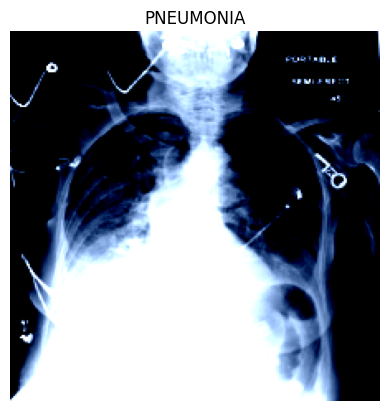

In [39]:
import matplotlib.pyplot as plt

plt.imshow(sample["image"].permute(1, 2, 0))
plt.title(ID2LABEL[sample["label"].item()])
plt.axis("off")
